In [18]:
import numpy as np
from scipy.sparse import coo_matrix


def load_base_matrix_from_text(filename):
    """
    Loads a base matrix from a text file.
    Each line corresponds to a row of integers.
    Returns a 2D NumPy array with shape (R, C).
    """
    rows = []
    
    with open(filename, 'r') as f:
        for line in f:
            # Strip whitespace, split by spaces
            str_vals = line.strip().split()
            # Convert each token to an int
            int_vals = list(map(int, str_vals))
            rows.append(int_vals)
    
    # Convert list of lists into a NumPy array
    # This assumes all rows have the same length
    base_matrix = np.array(rows, dtype=int)
    
    return base_matrix

def expand_submatrix(shift, Z):
    """
    Given a shift value and a lifting factor Z,
    return the Z x Z submatrix (in sparse format) that represents
    a cyclic shift (if shift >= 0) or a zero matrix (if shift == -1).
    """
    if shift == -1:
        # No connection => Zero submatrix
        data = []
        row = []
        col = []
        return coo_matrix((data, (row, col)), shape=(Z, Z))

    # For a shift >= 0, create a ZxZ identity matrix shifted by 'shift' columns (mod Z).
    # The (i, i+shift mod Z) = 1 for i in [0..Z-1].
    data = np.ones(Z, dtype=int)
    row = np.arange(Z)
    col = (row + shift) % Z
    return coo_matrix((data, (row, col)), shape=(Z, Z))

def create_5g_nr_parity_check_matrix(base_graph='BG1', Z=4):
    """
    Construct a 5G NR-like parity-check matrix H for demonstration.
    base_graph: 'BG1' or 'BG2'
    Z: lifting factor (must be a positive integer, typically up to 384)
    
    Returns: A scipy.sparse.coo_matrix representing the parity-check matrix.
    """
    # ------------------------------------------------
    # 1) Define a *partial* base graph from 3GPP 38.212 
    #    to keep it short. In reality, you need the full matrix.
    # 
    #    -1 means no edge
    #    0..(Z-1) means a shifted identity submatrix
    #
    #    BG1 is 46 x 68 in real 5G, BG2 is 42 x 52.
    # ------------------------------------------------
    
    if base_graph == 'BG1':
        # Partial BG1 example (4 rows x 6 cols)
        # Real BG1 is 46 x 68. This is just an example subset:
        base_graph_matrix = load_base_matrix_from_text('base_matrices/NR_1_7_60.txt')
    else:
        # Partial BG2 example (again, not the full matrix)
        # Real BG2 is 42 x 52. 
        base_graph_matrix = load_base_matrix_from_text('base_matrices/NR_1_1_384.txt')
    
    R, C = base_graph_matrix.shape
    
    # ------------------------------------------------
    # 2) Expand the base graph
    # ------------------------------------------------
    big_data = []
    big_row = []
    big_col = []
    
    for r in range(R):
        for c in range(C):
            sub_H = expand_submatrix(base_graph_matrix[r, c], Z)
            
            # The top-left corner of the submatrix in the full H
            row_offset = r * Z
            col_offset = c * Z
            
            # Convert sub_H into COO to extract data, row, col
            sub_H_coo = sub_H.tocoo()
            
            # Append to global row/col/data
            big_data.extend(sub_H_coo.data)
            big_row.extend(sub_H_coo.row + row_offset)
            big_col.extend(sub_H_coo.col + col_offset)
    
    # Final matrix size is (R*Z) x (C*Z)
    H = coo_matrix((big_data, (big_row, big_col)), shape=(R*Z, C*Z), dtype=int)
    
    return H

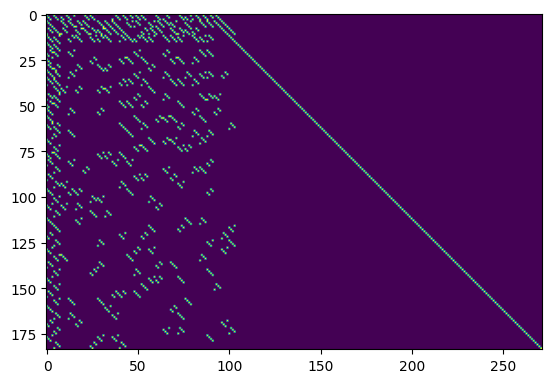

In [73]:
import matplotlib.pyplot as plt
import commpy.channelcoding.ldpc as ldpc

H = create_5g_nr_parity_check_matrix(base_graph='BG1', Z=4)*np.eye(272)
ldpc.write_ldpc_params(H, '5g_nr_ldpc_params.txt')
plt.imshow(H)

In [76]:


wimax = ldpc.get_ldpc_code_params(ldpc_design_filename='5g_nr_ldpc_params.txt', compute_matrix=True)

codeword = ldpc.triang_ldpc_systematic_encode(np.array([1,0,1,0,1,1,0,1,0,1,1,0]), wimax, 1)



codeword_to_llr = np.array([10 if x == 0 else -10 for x in codeword])
codeword_to_llr[0] = -1
decoded = ldpc.ldpc_bp_decode(codeword_to_llr, wimax,decoder_algorithm = "SPA", n_iters=100)

In [78]:
decoded[0]

array([1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0,
       1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0,
       1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0,
       1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1,
       1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1,
       0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 1, 1, 0, 1, 1], dtype=int8)

In [13]:
import numpy as np
from commpy.channelcoding.ldpc import get_ldpc_code_params, triang_ldpc_systematic_encode

def generate_ldpc_codeword(base_graph, Z, message_bits):
    """
    Generate an LDPC codeword using CommPy for a given base graph and expansion factor.

    Parameters:
        base_graph (2D list): Base graph matrix for LDPC (e.g., 5G-NR LDPC base graphs).
        Z (int): Expansion factor.
        message_bits (numpy array): Message bits to encode.

    Returns:
        numpy array: Encoded LDPC codeword.
    """
    # Step 1: Generate the expanded parity-check matrix
    n_rows, n_cols = len(base_graph), len(base_graph[0])
    n_vnodes = n_cols * Z  # Number of variable nodes
    n_cnodes = n_rows * Z  # Number of check nodes
    parity_check_matrix = np.zeros((n_cnodes, n_vnodes), dtype=int)

    for i in range(n_rows):
        for j in range(n_cols):
            if base_graph[i][j] != -1:  # Skip -1 (no connection)
                shift = base_graph[i][j] % Z  # Cyclic shift
                for k in range(Z):  # Build cyclically shifted identity matrices
                    parity_check_matrix[i * Z + k][j * Z + (k + shift) % Z] = 1

    # Step 2: Create LDPC parameters
    ldpc_params = {
        'parity_check_matrix': parity_check_matrix,
        'cnode_deg_list': [Z] * n_cnodes,
        'vnode_deg_list': [Z] * n_vnodes,
        'n_cnodes': n_cnodes,
        'n_vnodes': n_vnodes,
        'cnode_adj_list': np.array([[] for _ in range(n_cnodes*Z)]),
        'vnode_adj_list': np.array([[] for _ in range(n_vnodes*Z)]),
        'cnode_type': 'CT',
        'vnode_type': 'VN',
        'max_cnode_deg': Z,
        'max_vnode_deg': Z



        
        
    }

    # Step 3: Encode message using CommPy's systematic encoder
    codeword = triang_ldpc_systematic_encode(message_bits, ldpc_params)
    return codeword

# Example Usage
if __name__ == "__main__":
    # Example 5G-NR LDPC base graph (BG2)
    base_graph = [
        [1, -1, 0, -1],
        [-1, 1, 2, -1],
        [2, 0, -1, 1]
    ]

    # Expansion factor
    Z = 4  # Example Z value

    # Message bits
    message_bits = np.array([1, 0, 1, 0])  # Replace with your message

    # Generate LDPC codeword
    codeword = generate_ldpc_codeword(base_graph, Z, message_bits)
    print("Encoded Codeword:", codeword)


ValueError: cannot reshape array of size 0 into shape (12,4)

In [22]:
import ldpc
import ldpc.code_util
import numpy as np
from scipy.sparse import coo_matrix
import scipy.io as sio
import numpy as np
from scipy.sparse import coo_matrix
import ldpc.code_util
from ldpc.bp_decoder import BpDecoder


def load_parity_check_matrix_from_struct(mat_filename, struct_var='LDPC', field='H'):
    """
    Loads a MATLAB struct from 'mat_filename', looks up the field 'H' (or any
    other you specify), and returns that as a sparse COO matrix.
    """
    # Load the .mat file
    mat_data = sio.loadmat(mat_filename)
    # 'LDPC' is a structured array, probably shape (1,1).
    ldpc_struct = mat_data[struct_var]
    # If shape is (1,1), we do [0,0] to get the actual record
    ldpc_struct_elt = ldpc_struct[0,0]
    # Now grab the numeric matrix stored in the 'H' field
    H_dense = ldpc_struct_elt[field]  # e.g., 'H'
    # Convert to int
    H_dense = H_dense.astype(np.int64)
    # Make it sparse
    return coo_matrix(H_dense)

In [ ]:
import numpy as np
from scipy.sparse import coo_matrix
import ldpc.code_util
from ldpc.bp_decoder import BpDecoder

def load_base_matrix_from_text(filename):
    """
    Loads a base matrix from a text file.
    Each line corresponds to a row of integers.
    Returns a 2D NumPy array with shape (R, C).
    """
    rows = []
    
    with open(filename, 'r') as f:
        for line in f:
            # Strip whitespace, split by spaces
            str_vals = line.strip().split()
            # Convert each token to an int
            int_vals = list(map(int, str_vals))
            rows.append(int_vals)
    
    # Convert list of lists into a NumPy array
    # This assumes all rows have the same length
    base_matrix = np.array(rows, dtype=int)
    
    return base_matrix

def expand_submatrix(shift, Z):
    """
    Given a shift value and a lifting factor Z,
    return the Z x Z submatrix (in sparse format) that represents
    a cyclic shift (if shift >= 0) or a zero matrix (if shift == -1).
    """
    if shift == -1:
        # No connection => Zero submatrix
        data = []
        row = []
        col = []
        return coo_matrix((data, (row, col)), shape=(Z, Z))

    # For a shift >= 0, create a ZxZ identity matrix shifted by 'shift' columns (mod Z).
    # The (i, i+shift mod Z) = 1 for i in [0..Z-1].
    data = np.ones(Z, dtype=int)
    row = np.arange(Z)
    col = (row + shift) % Z
    return coo_matrix((data, (row, col)), shape=(Z, Z))

def create_5g_nr_parity_check_matrix(base_graph='BG1', Z=4):
    """
    Construct a 5G NR-like parity-check matrix H for demonstration.
    base_graph: 'BG1' or 'BG2'
    Z: lifting factor (must be a positive integer, typically up to 384)
    
    Returns: A scipy.sparse.coo_matrix representing the parity-check matrix.
    """
    # ------------------------------------------------
    # 1) Define a *partial* base graph from 3GPP 38.212 
    #    to keep it short. In reality, you need the full matrix.
    # 
    #    -1 means no edge
    #    0..(Z-1) means a shifted identity submatrix
    #
    #    BG1 is 46 x 68 in real 5G, but here we just show
    #    a 4 x 6 portion for illustration.
    # ------------------------------------------------
    
    if base_graph == 'BG1':
        # Partial BG1 example (4 rows x 6 cols)
        # Real BG1 is 46 x 68. This is just an example subset:
        base_graph_matrix = load_base_matrix_from_text('base_matrices/NR_1_0_128.txt')
    else:
        # Partial BG2 example (again, not the full matrix)
        # Real BG2 is 42 x 52. 
        base_graph_matrix = load_base_matrix_from_text('base_matrices/NR_2_0_128.txt')
    
    R, C = base_graph_matrix.shape
    
    # ------------------------------------------------
    # 2) Expand the base graph
    # ------------------------------------------------
    big_data = []
    big_row = []
    big_col = []
    
    for r in range(R):
        for c in range(C):
            sub_H = expand_submatrix(base_graph_matrix[r, c], Z)
            
            # The top-left corner of the submatrix in the full H
            row_offset = r * Z
            col_offset = c * Z
            
            # Convert sub_H into COO to extract data, row, col
            sub_H_coo = sub_H.tocoo()
            
            # Append to global row/col/data
            big_data.extend(sub_H_coo.data)
            big_row.extend(sub_H_coo.row + row_offset)
            big_col.extend(sub_H_coo.col + col_offset)
    
    # Final matrix size is (R*Z) x (C*Z)
    H = coo_matrix((big_data, (big_row, big_col)), shape=(R*Z, C*Z), dtype=int)
    
    return H

def demo_5g_ldpc_encode_decode():

    """
    1) Loads the parity-check matrix from a .mat file.
    2) Constructs a generator matrix G (if possible).
    3) Encodes a random message.
    4) Decodes (demo).
    """
    # ---------------------------
    # 1) Load the parity-check matrix
    # ---------------------------
  
    H = create_5g_nr_parity_check_matrix(base_graph='BG1', Z=4)
    print("Shape of H:", H.shape)

    # ---------------------------
    # 2) Construct the generator matrix
    # ---------------------------
    print("Constructing generator matrix...")
    G = ldpc.code_util.construct_generator_matrix(H)
    if G is None:
        print("Failed to construct generator matrix. "
              "Matrix might be too large, or rank/pivoting issue occurred.")
        return
    print("Shape of G:", G.shape)

    # ---------------------------
    # 3) Encode a random message
    #    Let k = number of rows in G => code dimension
    # ---------------------------
    k = G.shape[0]
    msg = np.random.randint(0, 2, size=k)
    codeword = (G.T @ msg) % 2
    print("Random message:", msg)
    print("Encoded codeword:", codeword)

    # ---------------------------
    # 4) Simple decode test via belief propagation
    #    In reality, you'd pass noisy channel LLRs. Here we just do a 'no-noise' test.
    # ---------------------------
    decoder = BpDecoder(H, error_rate=1e-5)
    # Create artificial 'perfect' LLRs: +∞ for 0 bits, -∞ for 1 bits
    # We'll use ±1000 as a large magnitude

    codeword[0]  = 1
    decoded_bits = decoder.decode(codeword)
    print("Decoded bits:", decoded_bits)

    # Compare decoded bits to the transmitted codeword
    num_errors = np.sum(decoded_bits != codeword)
    print(f"Number of bit errors in codeword domain: {num_errors}")
    return decoded_bits, G


if __name__ == "__main__":
    decded_codeword,G = demo_5g_ldpc_encode_decode()
    message = G@decded_codeword % 2
    print("Decoded message:", message)


Shape of H: (184, 272)
Constructing generator matrix...
Shape of G: (88, 272)
Random message: [1 1 1 1 1 0 1 0 0 0 0 1 0 1 0 1 0 0 1 1 0 0 0 0 1 0 0 1 0 0 1 1 0 0 0 1 0
 0 0 0 0 0 0 1 0 1 1 1 1 0 1 1 0 1 1 1 1 0 1 1 0 0 1 1 1 1 0 0 0 1 1 0 0 0
 0 0 1 1 1 1 0 1 0 1 1 1 0 1]
Encoded codeword: [0 1 1 1 1 0 1 0 0 0 0 0 1 0 0 1 1 0 0 1 0 1 0 0 1 1 1 1 1 1 0 1 1 1 1 1 0
 0 1 0 1 1 1 0 1 1 1 1 1 0 0 1 1 1 1 0 0 1 1 1 0 0 1 1 0 0 1 0 1 1 1 0 0 0
 1 0 0 0 0 1 0 0 0 1 1 0 1 0 0 0 1 0 1 1 0 0 1 1 1 0 1 1 1 1 0 1 0 0 1 0 0
 0 0 0 0 0 0 1 1 1 1 1 1 0 0 1 1 0 1 0 0 1 0 1 0 0 0 1 0 1 1 0 0 0 0 1 1 1
 1 0 0 1 0 1 1 0 1 0 1 0 1 1 1 0 1 1 1 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 1 1 1
 1 1 1 1 0 1 0 0 0 0 1 0 1 0 1 0 0 1 1 0 0 0 0 1 0 0 1 0 0 1 1 0 0 0 1 0 0
 0 0 0 0 0 1 0 1 1 1 1 0 1 1 0 1 1 1 1 0 1 1 0 0 1 1 1 1 0 0 0 1 1 0 0 0 0
 0 1 1 1 1 0 1 0 1 1 1 0 1]
Decoded bits: [0 1 1 1 1 0 1 0 0 0 0 0 1 0 0 1 1 0 0 1 0 1 0 0 1 1 1 1 1 1 0 1 1 1 1 1 0
 0 1 0 1 1 1 0 1 1 1 1 1 0 0 1 1 1 1 0 0 1 1 1 0 0 1 1 0 0 1 0 1 1

In [24]:
import numpy as np


def load_base_matrix_from_text(filename):
    """
    Loads a base matrix from a text file.
    Each line corresponds to a row of integers.
    Returns a 2D NumPy array with shape (R, C).
    """
    rows = []
    
    with open(filename, 'r') as f:
        for line in f:
            # Strip whitespace, split by spaces
            str_vals = line.strip().split()
            # Convert each token to an int
            int_vals = list(map(int, str_vals))
            rows.append(int_vals)
    
    # Convert list of lists into a NumPy array
    # This assumes all rows have the same length
    base_matrix = np.array(rows, dtype=int)
    
    return base_matrix

def mul_sh(vec, shift):
    """
    Circularly shift the 1D numpy array `vec` to the left by `shift` positions.
    If shift == -1, return an array of zeros (i.e., treat as no contribution).
    Adjust as needed if your convention for shift is different.
    """
    if shift == -1:
        return np.zeros_like(vec)
    shift = shift % len(vec)  # ensure shift is within [0, len(vec))
    return np.roll(vec, -shift)  # left circular shift by `shift`


def nrldpc_encode(B, z, msg):
    """
    Python equivalent of the MATLAB code:

        cword = nrldpc_encode(B, z, msg)

    Arguments:
    ----------
    B   : 2D numpy array (the base matrix), shape (m, n)
    z   : int (expansion factor)
    msg : 1D numpy array of length (n - m)*z, containing the message bits

    Returns:
    --------
    cword : 1D numpy array of length n*z, containing the codeword bits.
    """
    m, n = B.shape

    # Initialize codeword array of length n*z
    cword = np.zeros(n * z, dtype=int)

    # Place message bits in the first (n - m)*z positions
    cword[: (n - m) * z] = msg

    temp = np.zeros(z, dtype=int)
    for i in range(4):              # i = 0..3 in Python
        for j in range(n - m):      # j = 0..(n-m-1)
            shift_val = B[i, j]     # B(i+1, j+1) in MATLAB
            segment = msg[j * z : (j + 1) * z]
            temp = (temp + mul_sh(segment, shift_val)) % 2

    if B[1, n - m] == -1:
        p1_sh = B[2, n - m]
    else:
        p1_sh = B[1, n - m]

    start = (n - m) * z
    end   = (n - m + 1) * z
    cword[start:end] = mul_sh(temp, z - p1_sh)

    for i_ in range(1, 4):  # i_ = 1..3 (MATLAB)
        temp = np.zeros(z, dtype=int)
        for j_ in range(1, (n - m) + i_ + 1):
            shift_val = B[i_ - 1, j_ - 1]  # row (i_-1), col (j_-1)
            segment = cword[(j_ - 1) * z : j_ * z]
            temp = (temp + mul_sh(segment, shift_val)) % 2

        start = (n - m + i_ - 1) * z
        end   = (n - m + i_) * z
        cword[start:end] = temp

    for i_ in range(5, m + 1):       # i_ = 5..m (MATLAB)
        row_idx = i_ - 1            # zero-based
        temp = np.zeros(z, dtype=int)
        for j_ in range(1, (n - m) + 4 + 1):  # j_ = 1..(n-m+4)
            shift_val = B[row_idx, j_ - 1]
            segment = cword[(j_ - 1) * z : j_ * z]
            temp = (temp + mul_sh(segment, shift_val)) % 2

        start = (n - m + i_ - 2) * z
        end   = (n - m + i_ - 1) * z
        cword[start:end] = temp

    return cword

msg = np.random.randint(0, 2, 88)
print("Message bits:", msg)
BG = load_base_matrix_from_text('base_matrices/NR_1_0_128.txt')
Z = 4
cword= nrldpc_encode(BG, z= 4, msg=msg)
cword.shape


Message bits: [1 0 1 0 0 1 1 0 1 1 1 1 1 0 0 1 1 1 0 1 0 1 0 0 1 1 1 1 1 0 0 1 1 1 0 0 0
 1 0 1 0 0 1 1 0 1 0 1 0 0 1 1 1 0 1 1 0 0 0 1 1 1 1 1 1 0 0 1 0 1 1 0 1 1
 1 0 0 0 1 0 0 0 1 1 1 0 1 1]


(272,)

In [25]:
def expand_ldpc_base_matrix(B, z):
    """
    Expand a base matrix B into a full parity-check matrix H using
    cyclically shifted identity submatrices of size z x z.
    
    Args:
        B (np.ndarray): The base matrix (shape: [m, n]).
        z (int): Expansion factor.
    
    Returns:
        H (np.ndarray): The expanded parity-check matrix (shape: [m*z, n*z]).
    """
    import numpy as np

    m, n = B.shape
    H = np.zeros((m * z, n * z), dtype=int)

    for i in range(m):
        for j in range(n):
            shift_val = B[i, j]
            if shift_val == -1:
                # This sub-block is all zeros, so do nothing
                continue
            else:
                # This sub-block is a z x z identity, cyclically shifted
                for row_in_subblock in range(z):
                    row_idx = i * z + ((row_in_subblock + shift_val) % z)
                    col_idx = j * z + row_in_subblock
                    H[row_idx, col_idx] = 1

    return H


def build_parity_check_structure(H):
    """
    Create adjacency information (row_to_cols and col_to_rows) for each
    check node and variable node in the parity-check matrix H.
    
    Args:
        H (np.ndarray): The expanded parity-check matrix, shape (M, N).
    
    Returns:
        row_to_cols (list of lists): row_to_cols[r] contains the indices
                                     of variable nodes connected to row r.
        col_to_rows (list of lists): col_to_rows[c] contains the indices
                                     of check nodes connected to column c.
    """
    import numpy as np

    M, N = H.shape
    row_to_cols = [[] for _ in range(M)]
    col_to_rows = [[] for _ in range(N)]

    # Find the nonzero entries of H
    rows, cols = np.nonzero(H)
    for r, c in zip(rows, cols):
        row_to_cols[r].append(c)
        col_to_rows[c].append(r)

    return row_to_cols, col_to_rows



def sum_product_decode(H, llr, max_iter=50):
    """
    Sum-Product (Belief-Propagation) Decoding for LDPC on bipartite graph H.

    H: (M x N) parity-check matrix of 0/1
    llr: N-dimensional array of log-likelihood ratios for each bit
    max_iter: maximum number of iterations

    Return:
        decoded_bits: N-dimensional array of hard-decoded bits (0/1)
    """
    M, N = H.shape

    # Build adjacency (which variable nodes connect to which check nodes, etc.)
    row_to_cols, col_to_rows = build_parity_check_structure(H)

    # Variable-to-Check messages: M_ij is the message from variable-node j to check-node i
    # Initialize with the channel LLR
    # We'll store them in a dictionary (i, j) => float
    v2c = {}
    for i in range(M):
        for j in row_to_cols[i]:
            v2c[(i, j)] = llr[j]  # start with channel LLR

    # Check-to-Variable messages: M_ij is the message from check-node i to variable-node j
    c2v = {}
    for i in range(M):
        for j in row_to_cols[i]:
            c2v[(i, j)] = 0.0

    # Iterative updates
    for _iteration in range(max_iter):
        # ---- 1) Check Node Update ----
        # For each check node i, update each message c2v[i, j] based on all other variable nodes connected
        for i in range(M):
            connected_vars = row_to_cols[i]
            if len(connected_vars) == 0:
                continue

            # Gather all incoming messages from variable nodes to check node i
            msgs = np.array([v2c[(i, j)] for j in connected_vars])

            # The sum-product check node update can be written as:
            # c2v[i,j] = 2 * atanh( product_k != j( tanh( v2c[i,k] / 2 ) ) ) (with sign/time tracking)
            # We'll use a more stable log/tanh-based approach or approximate. For simplicity:
            for j in connected_vars:
                # product of signs * ...
                product_of_tanh = 1.0
                sum_of_abs = 0.0  # We'll do a log-domain approach or direct approach

                for k in connected_vars:
                    if k == j:
                        continue
                    val = np.tanh(v2c[(i, k)] / 2.0)
                    product_of_tanh *= val

                # c2v[i, j] in "exact" sum-product:
                # = 2 * atanh( product_of_tanh )
                # Be mindful of numerical stability: atanh(x) ~ 0.5 * log((1+x)/(1-x))
                eps = 1e-12
                new_msg = 2.0 * np.arctanh(np.clip(product_of_tanh, -1+eps, 1-eps))
                c2v[(i, j)] = new_msg

        # ---- 2) Variable Node Update ----
        updated_bits = np.zeros(N)
        for j in range(N):
            connected_checks = col_to_rows[j]
            # Sum of channel LLR plus all check-to-variable messages
            total_llr = llr[j]
            for i in connected_checks:
                total_llr += c2v[(i, j)]

            # Hard decision: 0 if LLR>0, else 1  (assuming BPSK + AWGN)
            updated_bits[j] = 0 if total_llr >= 0 else 1

            # Now update v2c for next iteration
            for i in connected_checks:
                # v2c[i, j] = total_llr - c2v[i, j]
                # i.e. the "extrinsic" from all other check nodes
                v2c[(i, j)] = total_llr - c2v[(i, j)]

        # ---- 3) Parity Check ----
        # Check if all parity-check equations are satisfied
        # i.e., H * x^T = 0 (mod 2)
        # We can do a quick check in integer arithmetic:
        if _check_syndrome(H, updated_bits):
            # Success, early stop
            return updated_bits.astype(int)

    # If we exit loop, return last estimate
    return updated_bits.astype(int)


def _check_syndrome(H, bits):
    """
    Return True if syndrome is all zero => codeword is valid,
    else False.
    """
    # bits is a length N vector
    # H shape (M, N), so matrix multiplication => length M
    # We'll do mod 2
    syndrome = H.dot(bits) % 2
    return np.all(syndrome == 0)



def nrldpc_decode(B, z, received_llr, max_iter=50):
    """
    1) Expand base matrix B to parity-check matrix H.
    2) Run sum-product decoding (or min-sum) on the received LLRs.
    3) Return the estimated codeword bits.
    """
    # 1) Expand
    H = expand_ldpc_base_matrix(B, z)

    # 2) Decode
    decoded_bits = sum_product_decode(H, received_llr, max_iter=max_iter)

    return decoded_bits

def cword_to_llr_BPSK(cword, sigma2):
    """
    Convert a BPSK codeword (0/1) to LLRs assuming AWGN noise.
    cword: Numpy array of 0/1 bits
    sigma2: Noise variance (scalar)
    """
    return 2.0 * cword - 1.0 / sigma2

llr = cword_to_llr_BPSK(cword, .01)
print("LLRs:", llr)

decod_cword = nrldpc_decode(BG, Z, cword_to_llr_BPSK(cword, .1), max_iter=50)
decod_cword


LLRs: [ -98. -100.  -98. -100. -100.  -98.  -98. -100.  -98.  -98.  -98.  -98.
  -98. -100. -100.  -98.  -98.  -98. -100.  -98. -100.  -98. -100. -100.
  -98.  -98.  -98.  -98.  -98. -100. -100.  -98.  -98.  -98. -100. -100.
 -100.  -98. -100.  -98. -100. -100.  -98.  -98. -100.  -98. -100.  -98.
 -100. -100.  -98.  -98.  -98. -100.  -98.  -98. -100. -100. -100.  -98.
  -98.  -98.  -98.  -98.  -98. -100. -100.  -98. -100.  -98.  -98. -100.
  -98.  -98.  -98. -100. -100. -100.  -98. -100. -100. -100.  -98.  -98.
  -98. -100.  -98.  -98. -100. -100.  -98.  -98. -100. -100. -100.  -98.
 -100. -100.  -98.  -98.  -98.  -98. -100. -100. -100. -100. -100.  -98.
  -98.  -98.  -98.  -98.  -98. -100. -100.  -98. -100. -100. -100. -100.
  -98. -100. -100.  -98.  -98.  -98. -100. -100.  -98.  -98.  -98.  -98.
  -98. -100. -100.  -98. -100. -100.  -98. -100. -100. -100. -100.  -98.
 -100.  -98.  -98. -100.  -98. -100.  -98. -100.  -98.  -98.  -98.  -98.
 -100. -100.  -98. -100.  -98. -100.  -98. -1

array([1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0,
       1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1,
       1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1])

In [26]:
def extract_message_from_codeword(cword_dec, B, z):
    """
    Return the message bits from the decoded codeword cword_dec.

    Args:
        cword_dec (np.ndarray): Decoded codeword bits of length n*z.
        B (np.ndarray): Base matrix (shape m x n) from which we know
                        the partition of systematic and parity columns.
        z (int): Lifting factor.

    Returns:
        msg_dec (np.ndarray): Message bits of length (n - m)*z.
    """
    m, n = B.shape
    # The first (n - m)*z bits are the systematic (message) portion
    msg_dec = cword_dec[: (n - m) * z]
    return msg_dec

print("message:", msg)
print("cword:", cword)
print("decoded codeword:", decod_cword)


message: [1 0 1 0 0 1 1 0 1 1 1 1 1 0 0 1 1 1 0 1 0 1 0 0 1 1 1 1 1 0 0 1 1 1 0 0 0
 1 0 1 0 0 1 1 0 1 0 1 0 0 1 1 1 0 1 1 0 0 0 1 1 1 1 1 1 0 0 1 0 1 1 0 1 1
 1 0 0 0 1 0 0 0 1 1 1 0 1 1]
cword: [1 0 1 0 0 1 1 0 1 1 1 1 1 0 0 1 1 1 0 1 0 1 0 0 1 1 1 1 1 0 0 1 1 1 0 0 0
 1 0 1 0 0 1 1 0 1 0 1 0 0 1 1 1 0 1 1 0 0 0 1 1 1 1 1 1 0 0 1 0 1 1 0 1 1
 1 0 0 0 1 0 0 0 1 1 1 0 1 1 0 0 1 1 0 0 0 1 0 0 1 1 1 1 0 0 0 0 0 1 1 1 1
 1 1 0 0 1 0 0 0 0 1 0 0 1 1 1 0 0 1 1 1 1 1 0 0 1 0 0 1 0 0 0 0 1 0 1 1 0
 1 0 1 0 1 1 1 1 0 0 1 0 1 0 1 0 0 0 0 0 0 0 1 1 0 1 0 0 1 0 1 1 1 0 0 0 0
 0 0 1 1 0 1 1 0 0 0 0 1 0 0 0 0 1 0 1 0 0 0 1 1 0 1 0 1 0 0 0 0 0 0 1 0 1
 0 1 0 0 1 1 0 1 1 0 0 1 1 0 0 0 0 0 0 0 0 1 0 0 0 0 1 1 0 1 1 0 0 0 0 1 0
 0 1 0 1 0 1 0 1 0 0 0 0 0]
decoded codeword: [1 0 1 0 1 0 1 1 1 1 0 0 0 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1 0 1 0 0 1 1 1 1 1
 0 1 1 1 1 1 0 1 0 1 1 1 1 0 1 1 0 1 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1
 1 0 0 1 0 1 1 1 1 0 1 0 1 1 1 1 0 0 1 0 1 1 1 1 1 1 0 1 0 0 1 0 0 1 1 1 1
 1 1 1 1